HOSPITAL PATIENT DATA ANALYSIS

PATIENT COUNT BY DISEASE
Disease
Fever            4
Diabetes         4
Heart Disease    4
Asthma           3
Name: count, dtype: int64

PATIENT COUNT BY AGE GROUP
Age_Group
Children         0
Young Adults     5
Adults           4
Senior Adults    3
Elderly          3
Name: count, dtype: int64

PEAK ADMISSION MONTH: March


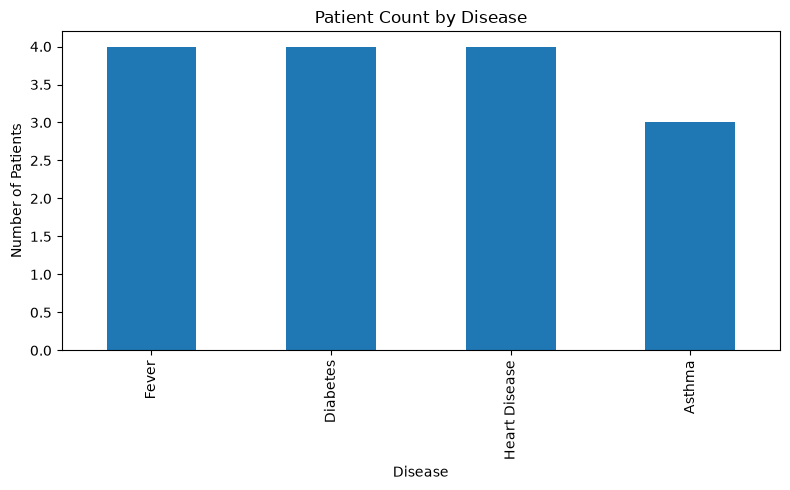

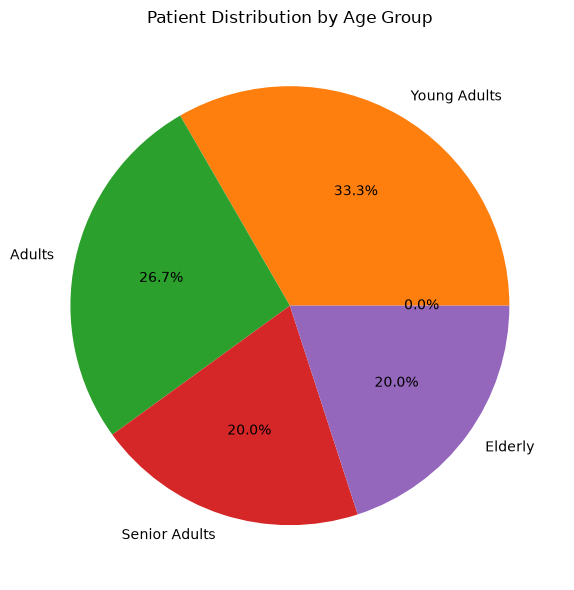

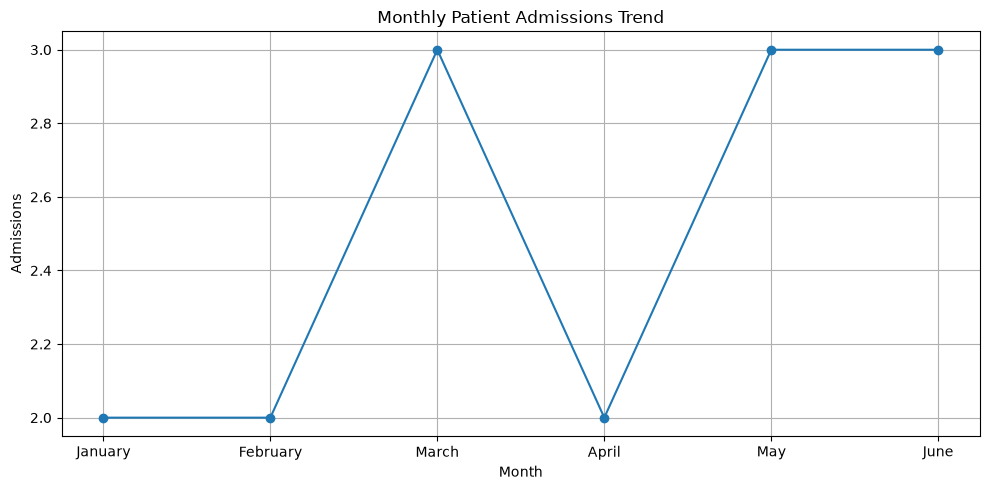


SUMMARY
Total Patients: 15
Most Common Disease: Fever
Peak Admission Month: March

Analysis Completed Successfully!


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Dataset
data = """
Patient_ID,Age,Disease,Gender,Admission_Date,Stay_Days
1,25,Fever,Male,2024-01-05,3
2,45,Diabetes,Female,2024-01-10,5
3,67,Heart Disease,Male,2024-02-12,10
4,34,Fever,Female,2024-02-15,2
5,55,Diabetes,Male,2024-03-01,6
6,72,Heart Disease,Female,2024-03-08,12
7,28,Asthma,Male,2024-03-15,4
8,39,Fever,Female,2024-04-05,3
9,61,Heart Disease,Male,2024-04-10,9
10,50,Diabetes,Female,2024-05-02,7
11,30,Asthma,Female,2024-05-11,5
12,42,Fever,Male,2024-05-20,2
13,70,Heart Disease,Female,2024-06-03,11
14,23,Asthma,Male,2024-06-12,3
15,58,Diabetes,Male,2024-06-25,8
"""

# Load Dataset
df = pd.read_csv(StringIO(data))

# Data Cleaning
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])

print("=" * 60)
print("HOSPITAL PATIENT DATA ANALYSIS")
print("=" * 60)

# Disease Analysis
disease_count = df["Disease"].value_counts()

print("\nPATIENT COUNT BY DISEASE")
print(disease_count)

# Age Group Analysis
bins = [0, 18, 35, 50, 65, 100]
labels = ["Children", "Young Adults", "Adults", "Senior Adults", "Elderly"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_group_count = df["Age_Group"].value_counts().sort_index()

print("\nPATIENT COUNT BY AGE GROUP")
print(age_group_count)

# Monthly Admissions
df["Month_Number"] = df["Admission_Date"].dt.month
df["Month"] = df["Admission_Date"].dt.month_name()

monthly_admissions = (
    df.groupby(["Month_Number", "Month"])
    .size()
    .reset_index(name="Admissions")
    .sort_values("Month_Number")
)

peak_month = monthly_admissions.loc[
    monthly_admissions["Admissions"].idxmax(),
    "Month"
]

print("\nPEAK ADMISSION MONTH:", peak_month)

# Chart 1 - Disease Count
plt.figure(figsize=(8, 5))
disease_count.plot(kind="bar")
plt.title("Patient Count by Disease")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

# Chart 2 - Age Group Distribution
plt.figure(figsize=(8, 6))
age_group_count.plot(kind="pie", autopct="%1.1f%%")
plt.title("Patient Distribution by Age Group")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Chart 3 - Monthly Admissions Trend
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_admissions["Month"],
    monthly_admissions["Admissions"],
    marker="o"
)
plt.title("Monthly Patient Admissions Trend")
plt.xlabel("Month")
plt.ylabel("Admissions")
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary
print("\nSUMMARY")
print("Total Patients:", len(df))
print("Most Common Disease:"
, disease_count.idxmax())
print("Peak Admission Month:", peak_month)

print("\nAnalysis Completed Successfully!")